# OVERVIEW

This notebook serves as examples and analysis of how to use accompanying src .py files

## *IMPORTS*

Script created in trading_bot project when encountering import issues due to notebook files and working in a different directory. same script added across every project. Also changed the names of plotting files to match the project name, as python automatically was chosing the first option when called. 

In [1]:
import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [2]:
import numpy as np

#from ml_trading_signals
from features import build_multi_ticker_dataset, build_momentum_equity_curve
from labels import excess_return_target
from walk_forward import walk_forward_momentum_rule

#from this projects src files
from position_sizing import kelly_sizing, kelly_from_returns, volatility_scaled_size 
from risk_limits import compute_drawdown, apply_drawdown_overlay, compute_var, compute_cvar, cvar_constrained_size, combined_position_size, combine_turnover_overlay, apply_transaction_costs, apply_volatility_overlay, correlation_penalty, apply_position_stops
from plotting_risk_management import plot_equity_drawdown_exposure, plot_position_sizing_comparison, plot_three_way_comparison, plot_all_risk_methods
from performance_evaluation import build_returns_by_method, build_exposure_by_method, compare_risk_methods

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## **Analysis**

Use the suggested method from Machine Learning Trading Signals to test our risk management approaches. Hence the same universe is also used.

In [3]:
#use the strategy selected in ml_trading_signals, namely 63 day momentum approach with weightings changed per 21 days (with fixed basket)
LOOKBACK_COL = 'return_63d'
TOP_FRAC = 0.20
REBALANCE_DAYS = 21

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM", "WMT", "PG", "HD", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ADBE", "CRM"]

pooled = build_multi_ticker_dataset(tickers, period="10y", horizon=21, ranking_horizon=21)
loaded_tickers = set(pooled['ticker'].unique())
missing_tickers = sorted(set(tickers) - loaded_tickers)

if missing_tickers: 
    raise RuntimeError(f"Analysis aborted because these tickers failed to load: {missing_tickers}") #analysis differed significantly on a run when 1 ticker's data failed to download

pooled_v2 = excess_return_target(pooled)

mom_wf_folds, mom_wf_daily = walk_forward_momentum_rule(pooled_v2, lookback_cols=[LOOKBACK_COL], top_fracs=[TOP_FRAC], horizon=21, train_size=504, test_size=63, embargo=21, expanding=True)
daily_equity = build_momentum_equity_curve(pooled_v2, lookback_col=LOOKBACK_COL, top_frac=TOP_FRAC, rebalance_days=REBALANCE_DAYS)

Successfully loaded: 20 / 20 tickers


Begin with kelly-optimal sizing - the fraction of your capital you should invest is given by:

$$
f = \frac{bp - q}{b} = p - \frac{q}{b}
$$
where $p$ is probability of 'winning' (making profit), $q = 1 - p$ and $b$ is payoff ratio. Often assumed $b \approx 1$. This estimate is known to be aggressive, so common for people to use half/quarter of this estimate.

In [20]:
strategy_returns = daily_equity.loc[~daily_equity['is_initial'],'portfolio_return'].dropna().astype(float)
nonzero_returns = strategy_returns[strategy_returns != 0]
wins = nonzero_returns[nonzero_returns > 0]
losses = nonzero_returns[nonzero_returns < 0]

win_probability = len(wins) / len(nonzero_returns)
win_loss_ratio = wins.mean() / abs(losses.mean())

f_actual = kelly_from_returns(strategy_returns, frac=1.0)

print(f"Historical win probability: {win_probability:.4f}")
print(f"Historical win/loss ratio:  {win_loss_ratio:.4f}")
print(f"Full Kelly estimate:         {f_actual:.4f}")
print(f"Half Kelly:                  {f_actual * 0.5:.4f}")
print(f"Quarter Kelly:               {f_actual * 0.25:.4f}")
print(f"Number of winning days:         {len(wins)}")
print(f"Number of losing days:          {len(losses)}")
print(f"Mean win:  {wins.mean() * 100:.4f}%")
print(f"Mean loss: {losses.mean() * 100:.4f}%")

Historical win probability: 0.5564
Historical win/loss ratio:  0.9843
Full Kelly estimate:         0.1057
Half Kelly:                  0.0528
Quarter Kelly:               0.0264
Number of winning days:         1362
Number of losing days:          1086
Mean win:  1.4298%
Mean loss: -1.4527%


In theory, the win/loss ratio is assumed to be 1. In practice, we see the win/loss ratio is 0.9843 $\approx$ 1, so our actual Kelly estimate will roughly align with its theoretical estimate

In [6]:
from garch_model import fit_garch, forecast_volatility

trailing_vol = strategy_returns.rolling(63).std().iloc[-1] * np.sqrt(252)
garch_fitted = fit_garch(strategy_returns)
garch_vol = forecast_volatility(garch_fitted, horizon=1)[0]

print(f"Trailing 63-day portfolio volatility: {trailing_vol:.4f}")
print(f"GARCH one-day portfolio forecast:     {garch_vol:.4f}")

size_trailing = volatility_scaled_size(target_risk=0.02, asset_vol=trailing_vol)
size_garch = volatility_scaled_size(target_risk=0.02, asset_vol=garch_vol)

print(f"\nPosition size using trailing volatility: {size_trailing:.4f}")
print(f"Position size using GARCH:               {size_garch:.4f}")

Trailing 63-day portfolio volatility: 0.3799
GARCH one-day portfolio forecast:     0.1859

Position size using trailing volatility: 0.0526
Position size using GARCH:               0.1076


Now turn our attention to circuit breakers. The momentum model from ml_trading_signals is adjusted slightly to make an equity curve, where the tickers are ranked by 63d momentum, we select the top 20%, and rebalance every 21 trading days. We implemented soft, hard limits based on the maximum drawdown of this method at 10%, 25% (when the max drawdown is below -10%, our exposure to the market decreases linearly from 1 until 0 (at 25%)). Intended to turn terrible losses into manageable ones. This is tested over the past 10 years with the plot below of the equity, max drawdown and exposure telling the story.

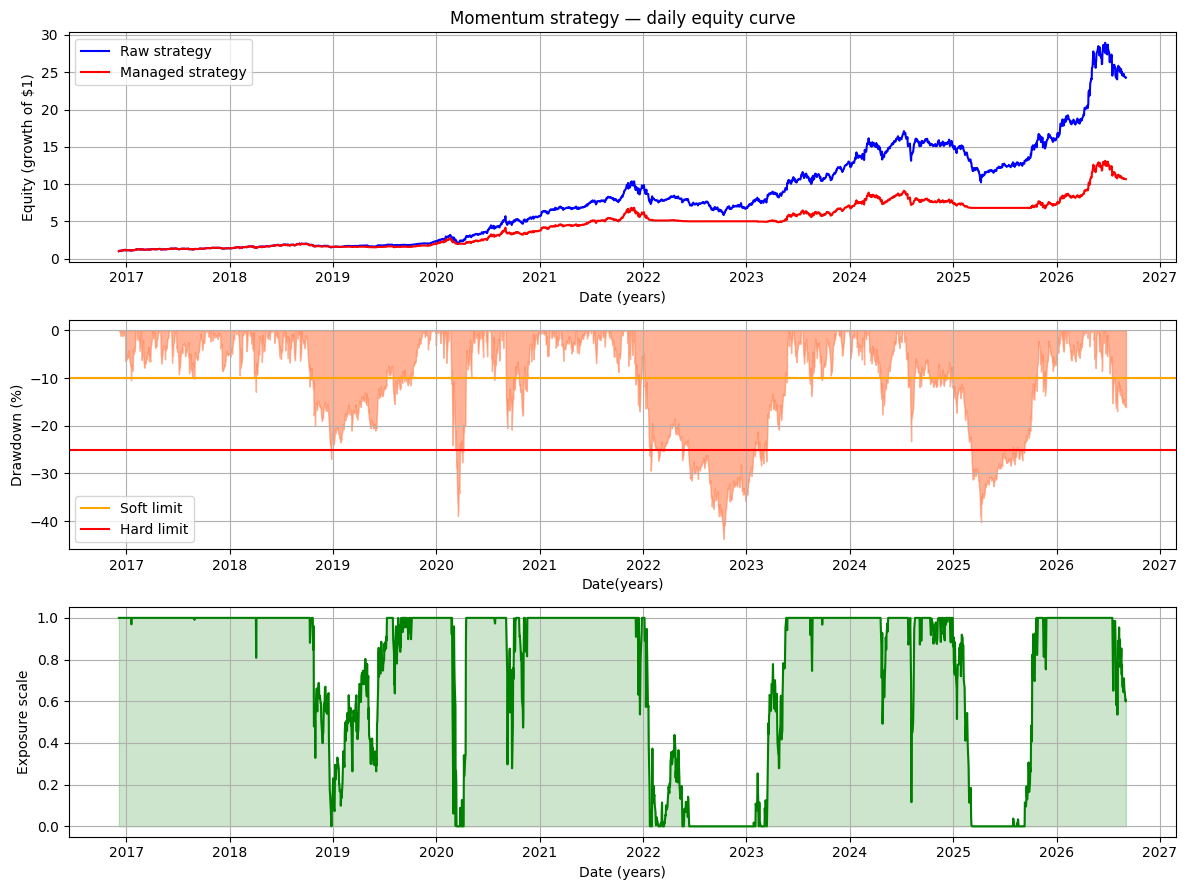

In [7]:
drawdown_result = apply_drawdown_overlay(daily_equity['portfolio_return'], soft_limit=-0.10, hard_limit=-0.25, initial_capital=1.0)

daily_dd = drawdown_result['reference_drawdown']
daily_exposure = drawdown_result['exposure']
managed_returns = drawdown_result['managed_return']
managed_equity = drawdown_result['managed_equity']

managed_dd = compute_drawdown(managed_equity)

plot_equity_drawdown_exposure(daily_equity, managed_equity, daily_dd, daily_exposure)

The design is working as planned. That is, in periods of high drawdown, we see the exposure of our portfolio decrease linearly. It is also clear that over time, the approach is not effective, that the approach without risk management performs better when judged by equity at every poiunt over the last 6-7 years of the backtest. Although the managed approaches seems to fare better in periods of maximum drawdown, the approach seems to take significantly longer to bounce back in comparison to the raw strategy, which causes it to lose out in the long run.

In [8]:

print(f"Percentage of time in reduced-exposure state: {(daily_exposure < 1.0).mean()*100:.2f}%")
print(f"Maximum Drawdown of Raw Strategy: {daily_dd.min() * 100:.4f}%")
print(f"Maximum Drawdown of Managed Strategy: {managed_dd.min() * 100:.4f}%")
print(f"Raw final equity:     {daily_equity['equity'].iloc[-1]:.2f}")
print(f"Managed final equity: {managed_equity.iloc[-1]:.2f}")

Percentage of time in reduced-exposure state: 39.32%
Maximum Drawdown of Raw Strategy: -43.7003%
Maximum Drawdown of Managed Strategy: -28.5043%
Raw final equity:     24.28
Managed final equity: 10.66


Despite the reduced equity, the managed strategy does reduce the max drawdown, perhaps as expected.

Now move on to VaR (value at risk) and CVaR (conditional value at risk). This is a function of a confidence level, x%. if VaR(x%) = -y%, then on x% of days we don't lose more than y%. If CVaR(x%) = -z%, then, given we're in the (100 - x) percentile, what is the expected loss? A common confidence level is 95%, which is what is implemented below.

In [22]:
rets = strategy_returns
print(f"VaR (95%):  {compute_var(rets)*100:.4f}%")
print(f"CVaR (95%): {compute_cvar(rets)*100:.4f}%")
print(f"Ratio (CVaR/VaR): {compute_cvar(rets)/compute_var(rets):.3f}")
print(f"\nCVaR-constrained size (3% budget): {cvar_constrained_size(rets, -0.03):.4f}")

VaR (95%):  -3.0425%
CVaR (95%): -4.7130%
Ratio (CVaR/VaR): 1.549

CVaR-constrained size (3% budget): 0.6365


CVaR constrained size is so that our size is limited to ensure that our position lays below our CVaR budget. Here we restrict our CVaR budget to -3% (don't allow a size which leaves the position with less than -3% CVaR), and hence the size is scaled down (since CVaR(95%) < -3%). Also notice, we lose more than ~3.04% on 95% of days, but if we are on one of those days, we expect to lose ~4.71%, showing how CVaR can be a more useful metric for measuring troughs in the market.

Now compose the 3 main methods of sizing into one. Aim to satisfy all 3 at once, as this intuitively means the approach is the safest.

In [10]:
final_size = combined_position_size(
    kelly_size=f_actual * 0.25,      #quarter Kelly from earlier
    vol_scaled_size=size_garch,       #GARCH from volatility scaling
    cvar_size=cvar_constrained_size(rets, cvar_budget=-0.03) #CVaR above
)
print(f"Kelly (quarter):      {f_actual*0.25:.4f}")
print(f"Volatility-scaled:    {size_garch:.4f}")
print(f"CVaR-constrained:     {cvar_constrained_size(rets, -0.03):.4f}")
print(f"\nFinal recommended size (min of all three): {final_size:.4f}")

Kelly (quarter):      0.0264
Volatility-scaled:    0.1076
CVaR-constrained:     0.6365

Final recommended size (min of all three): 0.0264


Now plot to see which sizing methods are taking priority

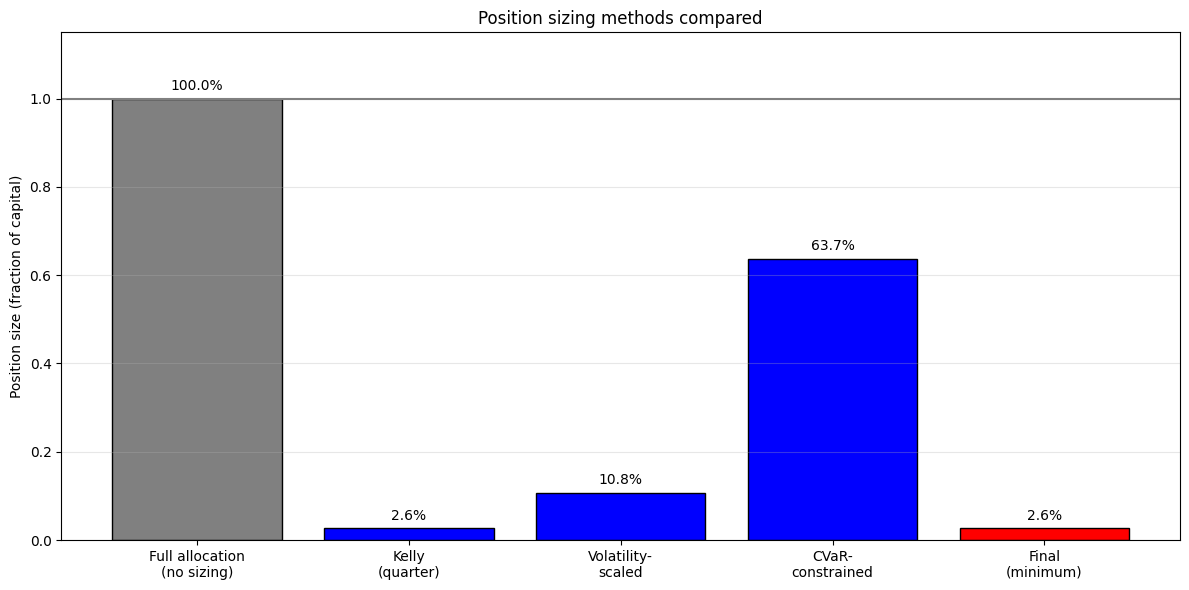

In [11]:
plot_position_sizing_comparison(f_actual*0.25, size_garch, cvar_constrained_size(rets, cvar_budget=-0.03), final_size)

From the plot, it is clear that satisfying the CVaR requirement is not difficult at all, the other 2 methods is where it becomes a factor.

Now move on to modelling transaction costs. Saw earlier that the circuit breaker approach was unsuccessful on the momentum strategy even without momentum costs, but we are still keen to see how transaction costs at each rebalance impact the final results.

In [12]:
turnover_breakdown = combine_turnover_overlay(base_turnover=daily_equity['turnover'], exposure=daily_exposure)

cost_result = apply_transaction_costs(returns=managed_returns, turnover=turnover_breakdown['total_turnover'], cost_bps=10, initial_capital=1.0)

managed_returns_net = cost_result['net_return']
managed_equity_net = cost_result['net_equity']

active_turnover = turnover_breakdown.loc[turnover_breakdown['total_turnover'] > 0, 'total_turnover']

print(f"Mean turnover when trading occurred: " f"{active_turnover.mean() * 100:.2f}%")
print(f"Number of turnover events: " f"{len(active_turnover)}")
print(f"\nManaged equity, gross: " f"{cost_result['gross_equity'].iloc[-1]:.2f}")
print(f"Managed equity, net of 10 bps costs: " f"{managed_equity_net.iloc[-1]:.2f}")

Mean turnover when trading occurred: 11.83%
Number of turnover events: 764

Managed equity, gross: 10.66
Managed equity, net of 10 bps costs: 9.74


This seems good on the surface, but it could be that this process is unstable, and as the costs are increasing from 0.05% to 1%, it could become catastrophic. This stability is tested below.

In [13]:
for cost_bps in [5, 10, 25, 50, 100]:
    scenario = apply_transaction_costs(returns=managed_returns, turnover=turnover_breakdown['total_turnover'], cost_bps=cost_bps, initial_capital=1.0)
    print(f"Cost {cost_bps:>3} bps: " f"final equity = {scenario['net_equity'].iloc[-1]:.2f}")

Cost   5 bps: final equity = 10.19
Cost  10 bps: final equity = 9.74
Cost  25 bps: final equity = 8.50
Cost  50 bps: final equity = 6.78
Cost 100 bps: final equity = 4.31


See a stability in this process. As expected, higher transaction costs mean more equity loss, but it is at a rate which seems logical.

Try a regime approach, where exposure is scaled down during periods of high volatility. Intuitively (and historically) momentum approaches tend to struggle in volatile times, so try this approach. Notice that this includes periods of high-upswing too, so potentially lose out there.

In [14]:
LOW_VOL_THRESHOLD = 0.15
HIGH_VOL_THRESHOLD = 0.35
MIN_REGIME_EXPOSURE = 0.20

volatility_result = apply_volatility_overlay(daily_equity['portfolio_return'], vol_window=21, low_vol_threshold=LOW_VOL_THRESHOLD, high_vol_threshold=HIGH_VOL_THRESHOLD, min_exposure=MIN_REGIME_EXPOSURE, initial_capital=1.0)

rolling_vol = volatility_result['rolling_vol']
regime_exposure = volatility_result['exposure']
regime_managed_returns = volatility_result['managed_return']
regime_managed_equity = volatility_result['managed_equity']
regime_dd = compute_drawdown(regime_managed_equity)

print(f"Days at or above the high-volatility threshold: " f"{(rolling_vol >= HIGH_VOL_THRESHOLD).sum()}")
print(f"Days with reduced applied exposure: " f"{(regime_exposure < 1.0).sum()}")
print(f"\nRegime-managed maximum drawdown: " f"{regime_dd.min() * 100:.2f}%")
print(f"Regime-managed final equity: " f"{regime_managed_equity.iloc[-1]:.2f}")

Days at or above the high-volatility threshold: 648
Days with reduced applied exposure: 2252

Regime-managed maximum drawdown: -31.33%
Regime-managed final equity: 5.25


Results don't look too good on the surface, which isn't too suprising as volatility is a price-neutral metric. It doesn't tell us whether the price is increasing or decreasing. Max drawdown tells us that the results are decreasing from a peak, so its only high (negatively) when the tickers price is reducing. The plot below gives more insight

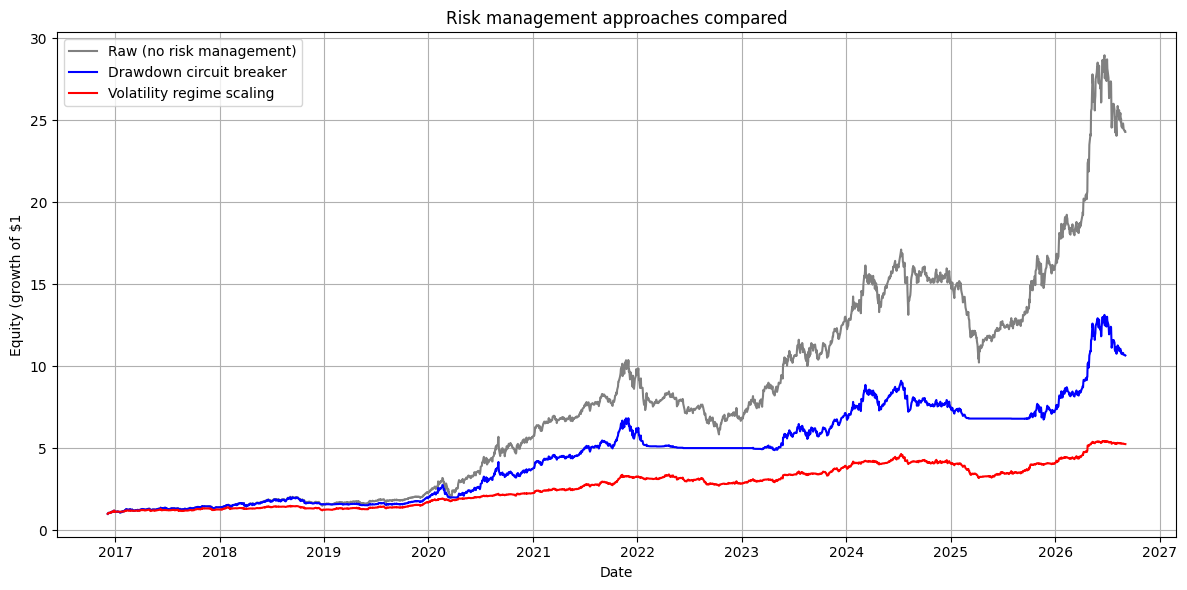

In [15]:
plot_three_way_comparison(daily_equity['equity'], managed_equity, regime_managed_equity)

Both approaches pale in comparison to no risk management on this strategy. It is key to note that this may not hold identically for other strategies, and risk management may be effective in managing turbulent periods.

Sometimes, tickers can have high correlation between them, so when things go bad, they go really bad. We test for this below.

In [16]:
rebalance_rows = daily_equity.loc[daily_equity['rebalanced']]
sample_date = rebalance_rows['signal_date'].iloc[-1]

day = pooled_v2.loc[pooled_v2.index == sample_date].dropna(subset=[LOOKBACK_COL])
day = day.sort_values([LOOKBACK_COL, 'ticker'], ascending=[False, True])

n_selected = max(1, int(len(day) * TOP_FRAC))
selection = tuple(day.head(n_selected)['ticker'])

print(f"Signal date: {sample_date.date()}")
print(f"Selected basket: {selection}")

penalty_scale, avg_corr = correlation_penalty(pooled_v2, selection, signal_date=sample_date, lookback_col='return_1d', window=63, min_obs=20, max_penalty=0.5)

print(f"Average pairwise correlation:       {avg_corr:.4f}")
print(f"Correlation-adjusted exposure scale: {penalty_scale:.4f}")

Signal date: 2026-08-17
Selected basket: ('JPM', 'AMD', 'JNJ', 'HD')
Average pairwise correlation:       -0.0294
Correlation-adjusted exposure scale: 1.0000


See that the correlation over time is very minimal over time, so no reason to implement this in more detail as effects will be minimal from raw strategy.

The last strategy tested here is a stop-loss approach. Think of the triple-labels approach from ml_trading_signals, trading ceases when the ticker hits the profit multiplier or the stop multiplier. The capital remains until the next 

In [17]:
stopped_equity, stop_events = apply_position_stops(pooled_v2, lookback_col=LOOKBACK_COL, top_frac=TOP_FRAC, rebalance_days=REBALANCE_DAYS, stop_mult=1.0, profit_mult=2.0, min_universe=5, initial_capital=1.0)
stopped_dd = compute_drawdown(stopped_equity['equity'])

n_stop_exits = (stop_events['outcome'] == 'stop').sum()
n_profit_exits = (stop_events['outcome'] == 'profit').sum()
n_cash_periods = (stopped_equity['cash_weight'] > 0).sum()

print(f"No position stops — final equity: " f"{daily_equity['equity'].iloc[-1]:.2f}, " f"maximum drawdown: {daily_dd.min() * 100:.2f}%")

print(f"With position barriers — final equity: " f"{stopped_equity['equity'].iloc[-1]:.2f}, " f"maximum drawdown: {stopped_dd.min() * 100:.2f}%")

print(f"\nStop-loss exits:   {n_stop_exits}")
print(f"Profit-target exits: {n_profit_exits}")
print(f"Periods containing cash: {n_cash_periods}")

No position stops — final equity: 24.28, maximum drawdown: -43.70%
With position barriers — final equity: 1.32, maximum drawdown: -19.80%

Stop-loss exits:   299
Profit-target exits: 164
Periods containing cash: 2384


The approach here also performs poorly, despite having a low max drawdown. This makes sense as rebalancing is done per 21 days, hence if a profit target or stop loss is hit hypothetically on the first day (or in theory any day before day 21), trading is ceased. If the porfolio performs well until the next rebalance, money is lost in comparison to other approaches as we have only cash. It is possible that performances improves if we shorten the rebalance period to say 1 week, then performance may improve, but this is a line of exploration for the future.

Have a plot below of the equity curve of all respective risk management approaches discussed in this project

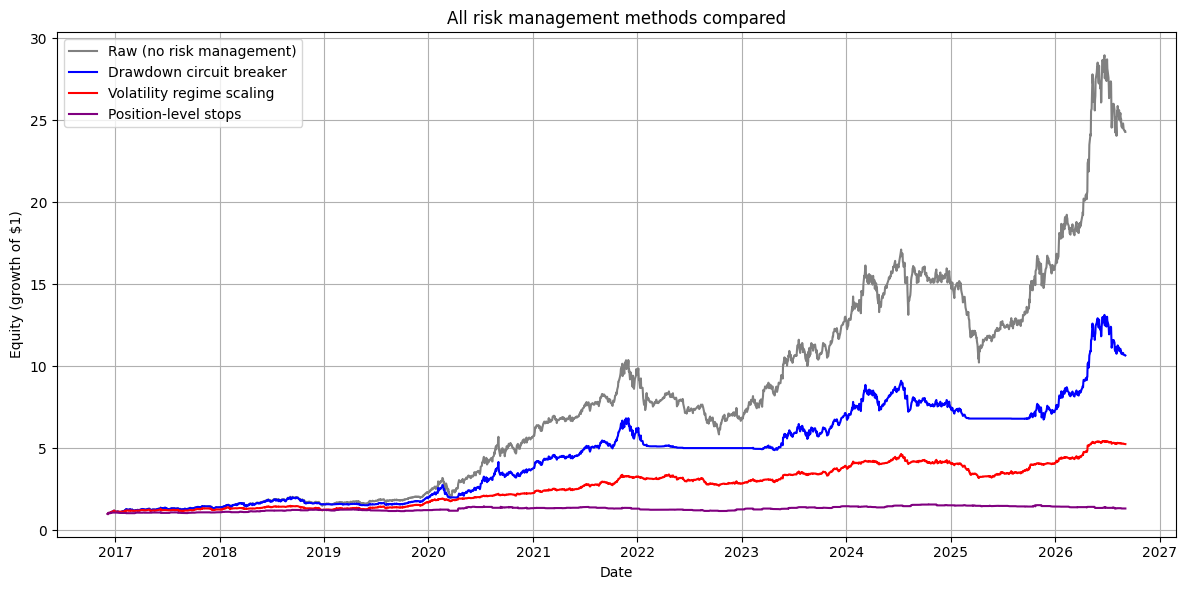

In [18]:
plot_all_risk_methods(daily_equity['equity'], managed_equity, regime_managed_equity, stopped_equity['equity'])

The results above are clearly damning for all risk approaches tested on this strategy. We created a table which summarises some key statistics across each method to show other perspectives apart from the equity curve.

In [19]:
returns_by_method = build_returns_by_method(raw_returns=daily_equity['portfolio_return'], drawdown_returns=managed_returns, volatility_returns=regime_managed_returns, barrier_returns=stopped_equity['portfolio_return'])
exposure_by_method = build_exposure_by_method(returns_by_method=returns_by_method, drawdown_exposure=daily_exposure, volatility_exposure=regime_exposure, barrier_cash_weight=stopped_equity['cash_weight'])

performance_table = compare_risk_methods(returns_by_method, exposure_by_method)

display(performance_table)

,Start,End,Observations,Final equity,CAGR (%),Annual volatility (%),Maximum drawdown (%),Sharpe,Calmar,Average exposure (%)
Method,,,,,,,,,,
Raw momentum,2016-12-06,2026-09-03,2449,24.283,38.742,32.257,-43.700,1.180,0.887,100.000
Drawdown overlay,2016-12-06,2026-09-03,2449,10.657,27.494,26.601,-28.504,1.049,0.965,75.147
Volatility overlay,2016-12-06,2026-09-03,2449,5.249,18.555,15.705,-31.327,1.165,0.592,55.798
Position barriers,2016-12-06,2026-09-03,2449,1.324,2.920,9.324,-19.804,0.356,0.147,13.304


There's some interesting things to note here. Firstly is the sharpe ratio of the raw strategy is the best, making it the best approach for returns per unit risk, even though the volatility overlay does come very close. The lowest max drawdown is achieved by the position barriers, despite its terrible performance in all other statistics. 